In [1]:
import numpy as np
np.random.seed(12)

from matplotlib import rc
import matplotlib.pyplot as plt
plt.rcParams['font.serif'] = ['CMU Serif']
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['font.size'] = 11

In [2]:
# Kernel function
def _kernel(grid):
    return np.exp(-1*(grid**2)/2)

In [3]:
# Define grid and some example samples
Xgrid = np.linspace(0, 1, 500)

# Feature 1 (Good)
sN1 = np.array([1.0, 0.548, 0.823])
sP1 = np.array([0.14, 0.0])
# Feature 2 (Bad)
sN2 = np.array([1.0, 0.548, 0.823])
sP2 = np.array([0.65, 0.5, 0.75])

In [4]:
# Implementing my own KDE function for educational purposes
def own_kde(_sample, bandwidth_rule):
    if bandwidth_rule=="scott":
        scottFactor = len(_sample)**(-1/5)
        bw = scottFactor * _sample.std(ddof=1)
    elif bandwidth_rule=="srot":
        q75, q25 = np.percentile(_sample, [75, 25])
        iqr = q75 - q25
        A = min(_sample.std(ddof=1), iqr/1.34)
        bw = 0.9 * A * len(_sample)**(-1/5)
        
    pde_manual = 0.
    pde_kernels = []
    for s in _sample:
        _in = (s - Xgrid) / bw
        pde_manual = pde_manual + _kernel(_in)
        pde_kernels.append(_kernel(_in) / (len(_sample)*bw*np.sqrt(2*np.pi)))

    pde_manual = pde_manual / (len(_sample)*bw*np.sqrt(2*np.pi))

    return pde_manual, pde_kernels

In [5]:
# KDE with Scott's rule for estimating bandwidth
pde_ownN1, pde_kernelsN1 = own_kde(sN1, "scott")
pde_ownP1, pde_kernelsP1 = own_kde(sP1, "scott")

pde_ownN2, pde_kernelsN2 = own_kde(sN2, "scott")
pde_ownP2, pde_kernelsP2 = own_kde(sP2, "scott")

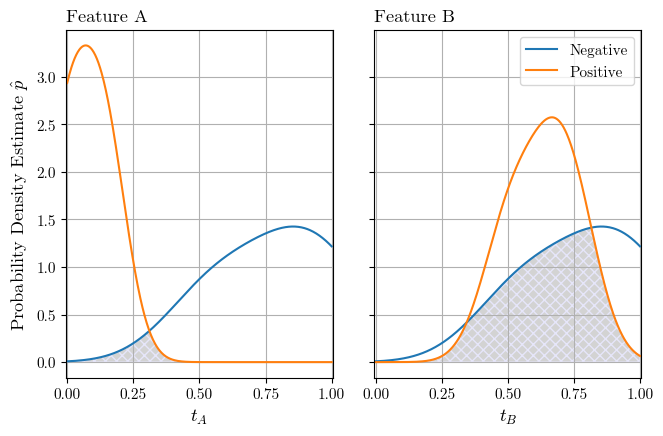

In [6]:
# Plots
plotlength = 9.0
fig2, ax2 = plt.subplots(
    1, 2, sharex=True, sharey=True, figsize=(plotlength/1.33, plotlength/2)
)

# Feature 1
ax2[0].plot(Xgrid, pde_ownN1, label="Negative")
ax2[0].plot(Xgrid, pde_ownP1, label="Positive")
# Getting intersection area
yStack1 = []
yStack1.append(pde_ownN1)
yStack1.append(pde_ownP1)
yIntersection1 = np.amin(yStack1, axis=0)
OA1 = np.trapz(yIntersection1, Xgrid)
fill_poly1 = ax2[0].fill_between(
    Xgrid, 0, yIntersection1,
    color="lightgray", edgecolor="lavender"
)
fill_poly1.set_hatch('xxx')

# Feature 2
ax2[1].plot(Xgrid, pde_ownN2, label="Negative")
ax2[1].plot(Xgrid, pde_ownP2, label="Positive")
# Getting intersection area
yStack2 = []
yStack2.append(pde_ownN2)
yStack2.append(pde_ownP2)
yIntersection2 = np.amin(yStack2, axis=0)
OA2 = np.trapz(yIntersection2, Xgrid)
fill_poly2 = ax2[1].fill_between(
    Xgrid, 0, yIntersection2,
    color="lightgray", edgecolor="lavender"
)
fill_poly2.set_hatch('xxx')

# x-ticks
ax2[0].set_xlim((-0.005, 1.005))
ax2[1].set_xlim((-0.005, 1.005))
ax2[0].set_xlabel(r"$t_A$", fontsize='large')
ax2[1].set_xlabel(r"$t_B$", fontsize='large')

# grids
ax2[0].grid(visible=True, which="major", axis="both")
ax2[1].grid(visible=True, which="major", axis="both")

# y-label
ax2[0].set_ylabel(r"Probability Density Estimate $\hat{p}$", fontsize='large')

# titles
ax2[0].set_title("Feature A", loc="left", fontsize='large')
ax2[1].set_title("Feature B", loc="left", fontsize='large')
plt.legend()
plt.tight_layout()
# plt.savefig("pdesegMainIdea.pdf", format="pdf")